In [4]:
# --- Core libraries ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  # optional, for interactive plots

# --- Time series / forecasting ---
from statsmodels.tsa.seasonal import seasonal_decompose

# --- Warnings and settings ---
import warnings
warnings.filterwarnings('ignore')

# --- Display options ---
pd.set_option('display.float_format', '{:,.0f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

In [5]:
#import datset
df = pd.read_csv('us_industry_employment.csv')

In [6]:
#Early phase of EDA
#Checking the dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   DateTime                              189 non-null    object
 1   Construction                          189 non-null    int64 
 2   Education and health services         189 non-null    int64 
 3   Financial activities                  189 non-null    int64 
 4   Information                           189 non-null    int64 
 5   Leisure and hospitality               189 non-null    int64 
 6   Manufacturing                         189 non-null    int64 
 7   Natural resources and mining          189 non-null    int64 
 8   Other services                        189 non-null    int64 
 9   Professional and business services    189 non-null    int64 
 10  Trade, transportation, and utilities  189 non-null    int64 
dtypes: int64(10), object(1)
memory u

In [8]:
df.describe()

,Construction,Education and health services,Financial activities,Information,Leisure and hospitality,Manufacturing,Natural resources and mining,Other services,Professional and business services,"Trade, transportation, and utilities"
count,189,189,189,189,189,189,189,189,189,189
mean,"6,741,868","22,179,365","8,125,328","2,825,947","15,479,513","12,356,788","1,815,466","4,430,926","20,241,111","26,879,016"
std,"970,292","2,006,790","461,015","116,181","1,310,477","430,325","96,915","178,586","1,876,797","1,365,219"
min,"5,239,000","18,757,000","7,442,000","2,682,000","13,254,000","11,423,000","1,601,000","4,075,000","16,575,000","24,350,000"
25%,"5,814,000","20,571,000","7,690,000","2,720,000","14,178,000","12,010,000","1,742,000","4,305,000","18,707,000","25,743,000"
50%,"6,911,000","22,348,000","8,139,000","2,797,000","15,801,000","12,330,000","1,816,000","4,433,000","20,358,000","27,146,000"
75%,"7,405,000","23,431,000","8,501,000","2,937,000","16,582,000","12,795,000","1,879,000","4,536,000","21,796,000","27,728,000"
max,"8,367,000","25,795,000","8,966,000","3,077,000","17,631,000","12,948,000","2,034,000","4,836,000","22,907,000","28,853,000"


# Employment Data Summary

## Count
Every numeric column has **189 entries**, meaning there are **no missing values** in the employment data.  
Good news: no need to handle nulls for analysis.

## Mean (Average Employment)
Average number of employees in each sector across the time period:

- **Construction:** ~6.75 million  
- **Education & Health Services:** ~21.7 million  
- **Manufacturing:** ~14.3 million  
- **Trade, Transportation, Utilities:** ~26.9 million  

**Insight:** Trade and Education sectors are the largest employers, while Natural Resources and Construction are smaller.

## Standard Deviation (std)
High std indicates more variation over time:

- **Leisure & Hospitality:** ~13 million  
- **Education & Health:** ~2 million  
- **Manufacturing:** ~6.9 million  

**Insight:** Leisure & Hospitality had bigger swings in employment (seasonal or economic effects), while Education & Health is relatively stable.

## Min / Max
- **Min values:** show the lowest employment recorded in the period.  
- **Max values:** show peaks.  

Examples:  
- Trade/Transportation/Utilities: ~2.68 million (min) to ~28.8 million (max) — consistently high employment  
- Natural Resources: ~1.78 million (min) to ~4.83 million (max) — consistently low employment  

## Percentiles (25%, 50%, 75%)
Show the distribution of employment:

- **Construction median:** ~6.91 million (50% of the time, employment is below this)  
- **Leisure & Hospitality 75% percentile:** ~16.5 million indicates high spikes compared to median (~1.58 million) — heavy variability or outliers

## Key Insights
- **Largest employers:** Trade/Transportation/Utilities and Education & Health Services  
- **Smaller employers:** Construction, Natural Resources, and Other Services  
- **Volatile sectors:** Leisure & Hospitality  
- **Stable sectors:** Education & Health Services  
- **Moderate variability:** Manufacturing, but consistently significant  
- **Potential outliers:** Sectors with very large max values relative to the mean (e.g., Leisure & Hospitality)


In [10]:
df.head()

,DateTime,Construction,Education and health services,Financial activities,Information,Leisure and hospitality,Manufacturing,Natural resources and mining,Other services,Professional and business services,"Trade, transportation, and utilities"
0,1/1/10 0:00,5390000,18825000,7553000,2752000,13419000,11457000,1634000,4400000,16632000,24821000
1,2/1/10 0:00,5359000,18795000,7517000,2739000,13334000,11434000,1655000,4382000,16616000,24571000
2,3/1/10 0:00,5319000,18757000,7481000,2735000,13254000,11423000,1669000,4366000,16575000,24356000
3,4/1/10 0:00,5302000,18781000,7473000,2729000,13278000,11434000,1684000,4374000,16624000,24350000
4,5/1/10 0:00,5297000,18806000,7471000,2723000,13315000,11471000,1700000,4381000,16658000,24367000


In [11]:
#sort by time
df = df.sort_values('DateTime')
df.head(100)

,DateTime,Construction,Education and health services,Financial activities,Information,Leisure and hospitality,Manufacturing,Natural resources and mining,Other services,Professional and business services,"Trade, transportation, and utilities"
0,1/1/10 0:00,5390000,18825000,7553000,2752000,13419000,11457000,1634000,4400000,16632000,24821000
12,1/1/11 0:00,5263000,19055000,7453000,2689000,13487000,11597000,1741000,4393000,17076000,24552000
24,1/1/12 0:00,5402000,19451000,7505000,2714000,13888000,11829000,1876000,4518000,17738000,25062000
36,1/1/13 0:00,5548000,20222000,7622000,2695000,14342000,11967000,1936000,4223000,18343000,25407000
48,1/1/14 0:00,5821000,20571000,7695000,2732000,14787000,12093000,1959000,4237000,18764000,25841000
...,...,...,...,...,...,...,...,...,...,...,...
27,4/1/12 0:00,5439000,19602000,7547000,2694000,14068000,11896000,1913000,4528000,17902000,25178000
39,4/1/13 0:00,5630000,20331000,7654000,2709000,14411000,11989000,1926000,4172000,18417000,25457000
51,4/1/14 0:00,5864000,20677000,7693000,2754000,14919000,12127000,1968000,4247000,18973000,25959000
63,4/1/15 0:00,6206000,21133000,7844000,2745000,15300000,12308000,1969000,4317000,19501000,26551000


In [12]:
#checking for duplicates
print("Duplicate dates:", df['DateTime'].duplicated().sum())


Duplicate dates: 0


In [13]:
#checking missing 
# check missing values by column
df.isnull().sum()


DateTime                                0
Construction                            0
Education and health services           0
Financial activities                    0
Information                             0
Leisure and hospitality                 0
Manufacturing                           0
Natural resources and mining            0
Other services                          0
Professional and business services      0
Trade, transportation, and utilities    0
dtype: int64

In [14]:
df.shape

(189, 11)

In [15]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [16]:
#fixing the datetime column

In [17]:
df.head()

,DateTime,Construction,Education and health services,Financial activities,Information,Leisure and hospitality,Manufacturing,Natural resources and mining,Other services,Professional and business services,"Trade, transportation, and utilities"
0,2010-01-01,5390000,18825000,7553000,2752000,13419000,11457000,1634000,4400000,16632000,24821000
12,2011-01-01,5263000,19055000,7453000,2689000,13487000,11597000,1741000,4393000,17076000,24552000
24,2012-01-01,5402000,19451000,7505000,2714000,13888000,11829000,1876000,4518000,17738000,25062000
36,2013-01-01,5548000,20222000,7622000,2695000,14342000,11967000,1936000,4223000,18343000,25407000
48,2014-01-01,5821000,20571000,7695000,2732000,14787000,12093000,1959000,4237000,18764000,25841000


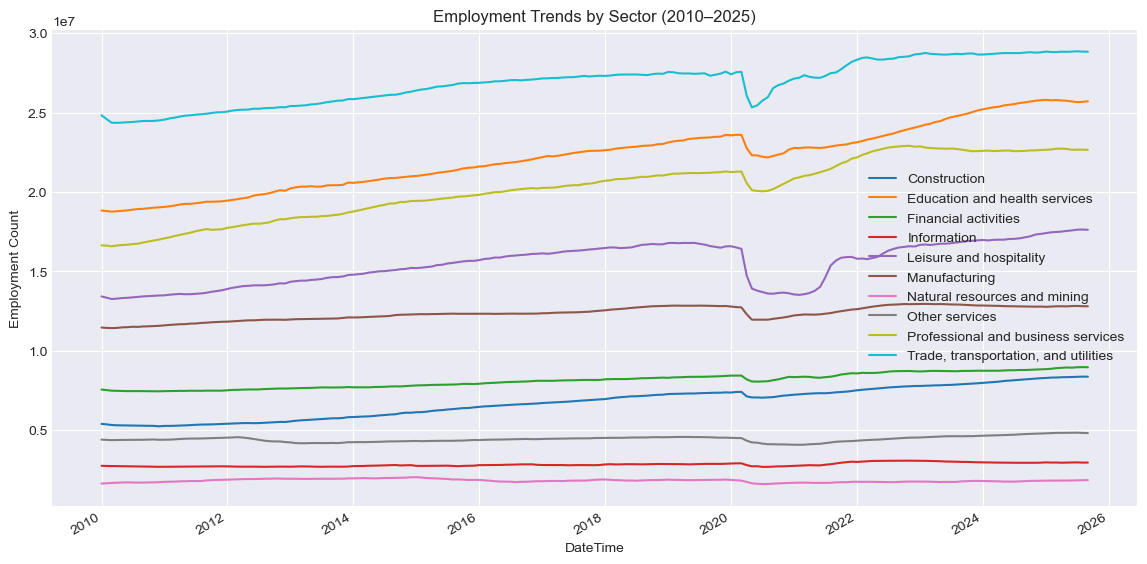

In [19]:
# Visualize overall employment trends -- Plot each industry over time:
df.set_index('DateTime').plot(figsize=(14,7))
plt.title("Employment Trends by Sector (2010–2025)")
plt.ylabel("Employment Count")
plt.show()

## Questions to answer:

Which sectors have grown the most since 2010?
- Top 5 : trade, trasportation, and utilities sector, education and health services, professional and bsuiness services industry sectors, leisure and hospitality, manufacturing.
- financial activities sector and constructuon sector show growth ,but its slower.

Which are stagnant or declining?
- information, other services, natural resources and mining are have been pretty stagnant so there a high chance that these industries could face decline in the job market.
  
Are there visible dips (like during COVID in 2020)?
- The top 5 industries are shown to grow over the given period, as compared to the bottom 5 industries that are either stagnacy or show minimum growth. When looked at top 5 there is a clear dip between 2020 to 2021, and nearing to 2022 there is a pick up in growth again.


## INSIGHTS:

📈 Sectors with the Most Growth (2010–2025)

These industries show strong upward trajectories in employment count:
Education and Health Services: Consistent and steep growth, reaching the highest employment count by 2025.
Professional and Business Services: Significant increase over time, with a sharp recovery post-2020 dip.
Trade, Transportation, and Utilities: Steady growth, especially after 2015, with a strong rebound after 2020.

🟡 Stagnant or Declining Sectors

These sectors show little growth or even slight declines:
Information: Relatively flat trend with minor fluctuations; no major growth.
Natural Resources and Mining: Lowest employment count throughout and mostly stagnant.
Manufacturing: Slight decline from 2010 to 2020, followed by a modest recovery but still below earlier levels.

📉 Visible Dips Around 2020 (COVID-19 Impact)

Yes, several sectors show a clear dip around 2020:
Leisure and Hospitality: Sharp decline in 2020, likely due to pandemic-related shutdowns, followed by a gradual recovery.
Trade, Transportation, and Utilities: Noticeable dip in 2020, then a strong rebound.
Professional and Business Services: Brief dip in 2020, quickly recovered.
Construction: Slight dip in 2020, then resumed growth.

In [24]:
##you can also compute total growth over the period:
growth = ((df.set_index('DateTime').iloc[-1] - df.set_index('DateTime').iloc[0]) / df.set_index('DateTime').iloc[0]) * 100
growth.sort_values(ascending=False)

Construction                           55
Education and health services          37
Professional and business services     36
Leisure and hospitality                31
Financial activities                   19
Trade, transportation, and utilities   16
Natural resources and mining           13
Manufacturing                          12
Other services                          9
Information                             7
dtype: float64

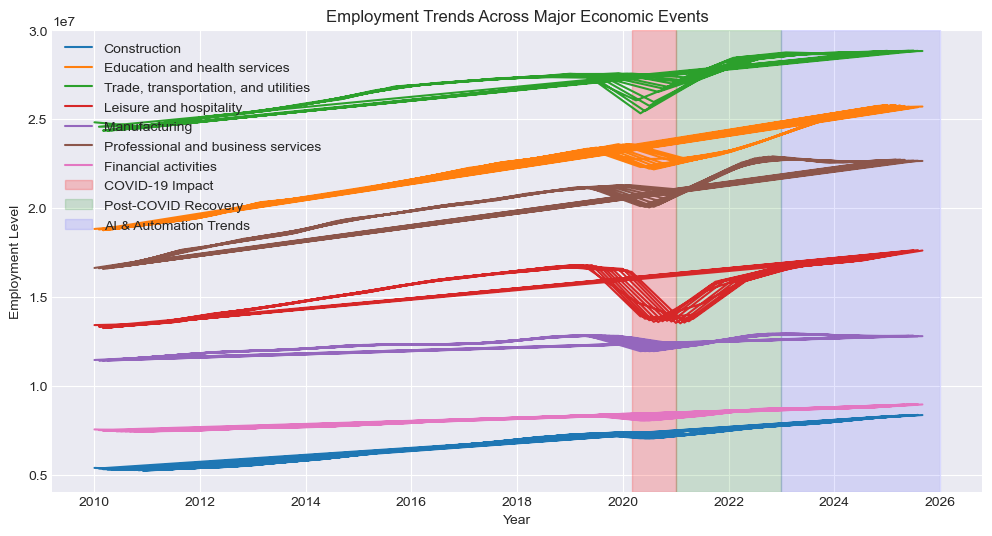

In [25]:
#Highlight major economic events
# Ensure DateTime column is in datetime format
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Select sectors you want to compare (you can adjust)
selected_sectors = ['Construction', 'Education and health services', 'Trade, transportation, and utilities',
                    'Leisure and hospitality', 'Manufacturing', 'Professional and business services', 'Financial activities']

# Plot over time
plt.figure(figsize=(12,6))
for sector in selected_sectors:
    plt.plot(df['DateTime'], df[sector], label=sector)

# Highlight key economic periods
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2020-12-31'), color='red', alpha=0.2, label='COVID-19 Impact')
plt.axvspan(pd.to_datetime('2021-01-01'), pd.to_datetime('2022-12-31'), color='green', alpha=0.15, label='Post-COVID Recovery')
plt.axvspan(pd.to_datetime('2023-01-01'), pd.to_datetime('2025-12-31'), color='blue', alpha=0.1, label='AI & Automation Trends')

plt.title('Employment Trends Across Major Economic Events')
plt.xlabel('Year')
plt.ylabel('Employment Level')
plt.legend()
plt.grid(True)
plt.show()


📉 COVID-19 Impact (2020)

Sharp decline across most industries, especially:

- Leisure and Hospitality: This sector saw the steepest drop, reflecting lockdowns and travel restrictions.
- Construction and Manufacturing: Also dipped due to halted projects and supply chain disruptions.
- Interpretation: COVID caused a sudden shock to labor markets, especially in consumer-facing and physical industries. This validates the need for career pivot tools during crisis periods.
    
📈 Post-COVID Recovery (2021–2022)

Gradual rebound in most sectors:
Education and Health Services recovered steadily, showing resilience and continued demand.
Trade, Transportation, and Utilities bounced back, likely due to increased e-commerce and logistics needs.
Leisure and Hospitality recovered but not to pre-COVID levels, suggesting long-term structural changes.
Interpretation: Recovery was uneven. Some sectors rebounded quickly, while others (like hospitality) may have permanently shifted. This helps identify which careers are stable vs. vulnerable.
🤖 AI & Automation Trends (2023–2024)
Divergence begins:
Information and Professional Services show upward trends, possibly driven by AI adoption, remote work, and tech demand.
Manufacturing and Construction appear to plateau, hinting at automation impacts or slower growth.
Interpretation: Emerging tech is reshaping job demand. Sectors tied to digital skills are growing, while manual labor sectors may face stagnation or transformation. This is crucial for forecasting future career paths.
🧠 Strategic Insights for Swytch
Career Pivot Guidance:
Encourage transitions into Information, Education/Health, and Professional Services — these show long-term growth.
Caution users about Leisure/Hospitality and Manufacturing, which are more volatile or automation-prone.
Event-Based Forecasting:
Use these shaded periods to train models that detect how external shocks (like pandemics or tech shifts) affect employment.
Sector Clustering:
Group sectors by behavior: resilient (health, education), cyclical (construction, trade), and tech-driven (information, professional services).

📉 COVID-19 Impact (2020)

Sharp decline across most industries, especially:

Leisure and Hospitality:

- This sector saw the steepest drop, reflecting lockdowns and travel restrictions.
- Construction and Manufacturing: Also dipped due to halted projects and supply chain disruptions.
- Interpretation: COVID caused a sudden shock to labor markets, especially in consumer-facing and physical industries. This validates the need for career pivot tools during crisis periods.
  
📈 Post-COVID Recovery (2021–2022)

Gradual rebound in most sectors:

- Education and Health Services recovered steadily, showing resilience and continued demand.
- Trade, Transportation, and Utilities bounced back, likely due to increased e-commerce and logistics needs.
- Leisure and Hospitality recovered but not to pre-COVID levels, suggesting long-term structural changes.
- Interpretation: Recovery was uneven. Some sectors rebounded quickly, while others (like hospitality) may have permanently shifted. This helps identify which careers are stable vs. vulnerable.
  
🤖 AI & Automation Trends (2023–2024)

Divergence begins:

- Information and Professional Services show upward trends, possibly driven by AI adoption, remote work, and tech demand.
- Manufacturing and Construction appear to plateau, hinting at automation impacts or slower growth.
- Interpretation: Emerging tech is reshaping job demand. Sectors tied to digital skills are growing, while manual labor sectors may face -- -- stagnation or transformation. This is crucial for forecasting future career paths.
  
🧠 Strategic Insights for Swytch

Career Pivot Guidance:

- Encourage transitions into Information, Education/Health, and Professional Services — these show long-term growth.
- Caution users about Leisure/Hospitality and Manufacturing, which are more volatile or automation-prone.
Event-Based Forecasting:

- Use these shaded periods to train models that detect how external shocks (like pandemics or tech shifts) affect employment.
  
Sector Clustering:

Group sectors by behavior: resilient (health, education), cyclical (construction, trade), and tech-driven (information, professional services).

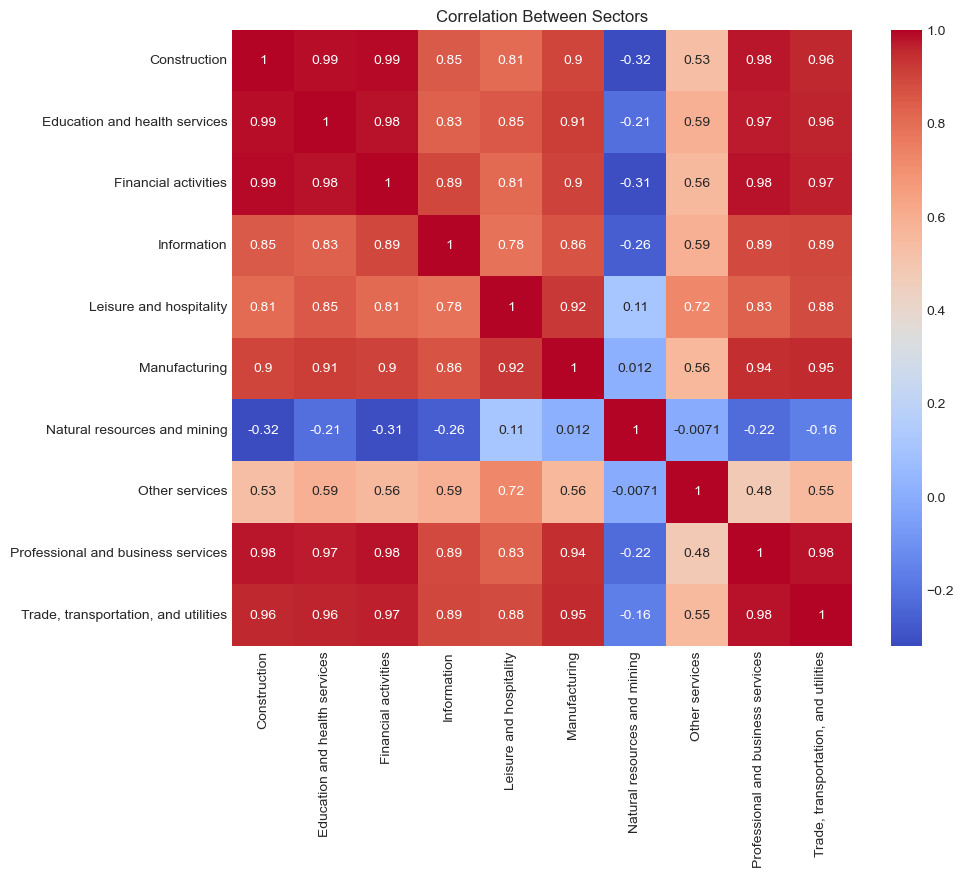

In [28]:
##Industrues that are linked
plt.figure(figsize=(10,8))
sns.heatmap(df.set_index('DateTime').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Sectors")
plt.show()

Industries that are linked:

Construction, Education and Health Services, Financial Activities, Manufacturing, Professional and Business Services, and Trade/Transportation/Utilities are all highly correlated.

This makes sense because these sectors depend on general economic growth. When the economy is doing well, people spend more, businesses expand, and there’s more demand for labor, buildings, education, and services. For example, when new businesses open or expand, construction projects increase, financial services are needed, and transportation/logistics activity rises.

Industries that are less linked or move differently:

Natural Resources and Mining has weak or even negative correlations with most other sectors.

This is because mining and resource extraction are driven more by global commodity prices, energy demand, and natural resource availability, not domestic consumer spending or business growth. So, even if the rest of the economy is growing, mining might slow down if oil or mineral prices drop.

Moderately linked industries:

Leisure and Hospitality and Information are somewhat connected to the broader economy but not as tightly as construction or finance. They depend on consumer confidence, technology trends, and discretionary spending, which can fluctuate differently from other sectors.

## further understanding questions/focuses for correlation:
Identifying these clusters of interrelated industries,

Explaining why certain sectors behave independently, and

Considering how these relationships could help predict job trends or measure economic stability over time.

In [31]:
df.head(100)

,DateTime,Construction,Education and health services,Financial activities,Information,Leisure and hospitality,Manufacturing,Natural resources and mining,Other services,Professional and business services,"Trade, transportation, and utilities"
0,2010-01-01,5390000,18825000,7553000,2752000,13419000,11457000,1634000,4400000,16632000,24821000
12,2011-01-01,5263000,19055000,7453000,2689000,13487000,11597000,1741000,4393000,17076000,24552000
24,2012-01-01,5402000,19451000,7505000,2714000,13888000,11829000,1876000,4518000,17738000,25062000
36,2013-01-01,5548000,20222000,7622000,2695000,14342000,11967000,1936000,4223000,18343000,25407000
48,2014-01-01,5821000,20571000,7695000,2732000,14787000,12093000,1959000,4237000,18764000,25841000
...,...,...,...,...,...,...,...,...,...,...,...
27,2012-04-01,5439000,19602000,7547000,2694000,14068000,11896000,1913000,4528000,17902000,25178000
39,2013-04-01,5630000,20331000,7654000,2709000,14411000,11989000,1926000,4172000,18417000,25457000
51,2014-04-01,5864000,20677000,7693000,2754000,14919000,12127000,1968000,4247000,18973000,25959000
63,2015-04-01,6206000,21133000,7844000,2745000,15300000,12308000,1969000,4317000,19501000,26551000
